In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from src.analysis_utils import (
    drop_missing,
    subset_variables,
    recode_vaccination_variables,
    chi2_cramers_v_weighted,
    normalized_crosstab,
    screen_categorical_associations,
    fit_weighted_logit,
    fit_weighted_ordinal_logit,
    extract_odds_ratios,
    plot_heatmap,
    plot_odds_ratios,
    plot_weighted_coverage_bar,
    plot_stacked_vaccination
)

In [2]:
# Path relative to script.py
csv_path = "../data/cleaned_data.csv"

# Read CSV
df = pd.read_csv(csv_path)

# Display first 5 rows
df.head()

,Mothers_id,Birth_Order,Cluster_id,Household_id,Respondents_line_number,v005,Childs_Age,Received_Hep_B_at_birth,Hep_B_1,Hep_B_2,...,hhid,Number_of_household_members,Number_of_children_under_5,Result_of_household_interview,Region,Type_of_place_of_residence,Translator_used,Vaccination_at_Birth,Vaccination_Flag,wt
0,205 12 2,2,205,12,2,552441,14,Vaccination date on card,No,No,...,205 12,4,2,Completed,Kampot,Urban,No,True,None Post Birth,0.552441
1,512 26 7,1,512,26,7,297079,8,Vaccination date on card,No,No,...,512 26,14,3,Completed,Preah Sihanouk,Rural,No,True,None Post Birth,0.297079
2,512 29 5,1,512,29,5,297079,4,No,No,No,...,512 29,6,1,Completed,Preah Sihanouk,Rural,No,False,None Post Birth,0.297079
3,641 16 1,2,641,16,1,64896,21,Vaccination date on card,No,No,...,641 16,3,2,Completed,Kep,Urban,No,True,None Post Birth,0.064896
4,513 6 1,4,513,6,1,287780,32,No,No,No,...,513 6,6,1,Completed,Preah Sihanouk,Rural,No,False,None Post Birth,0.287780


In [3]:
mothers_vars = [
    "Vaccination_at_Birth",
    "Vaccination_Flag",
    "Respondent_country_of_birth",
    "Wealth_index_combined",
    "Highest_educational_level",
    "Literacy",
    "Mothers_occupation",
    "Mothers_age",
    "wt"
]

df_test = df[mothers_vars].copy()

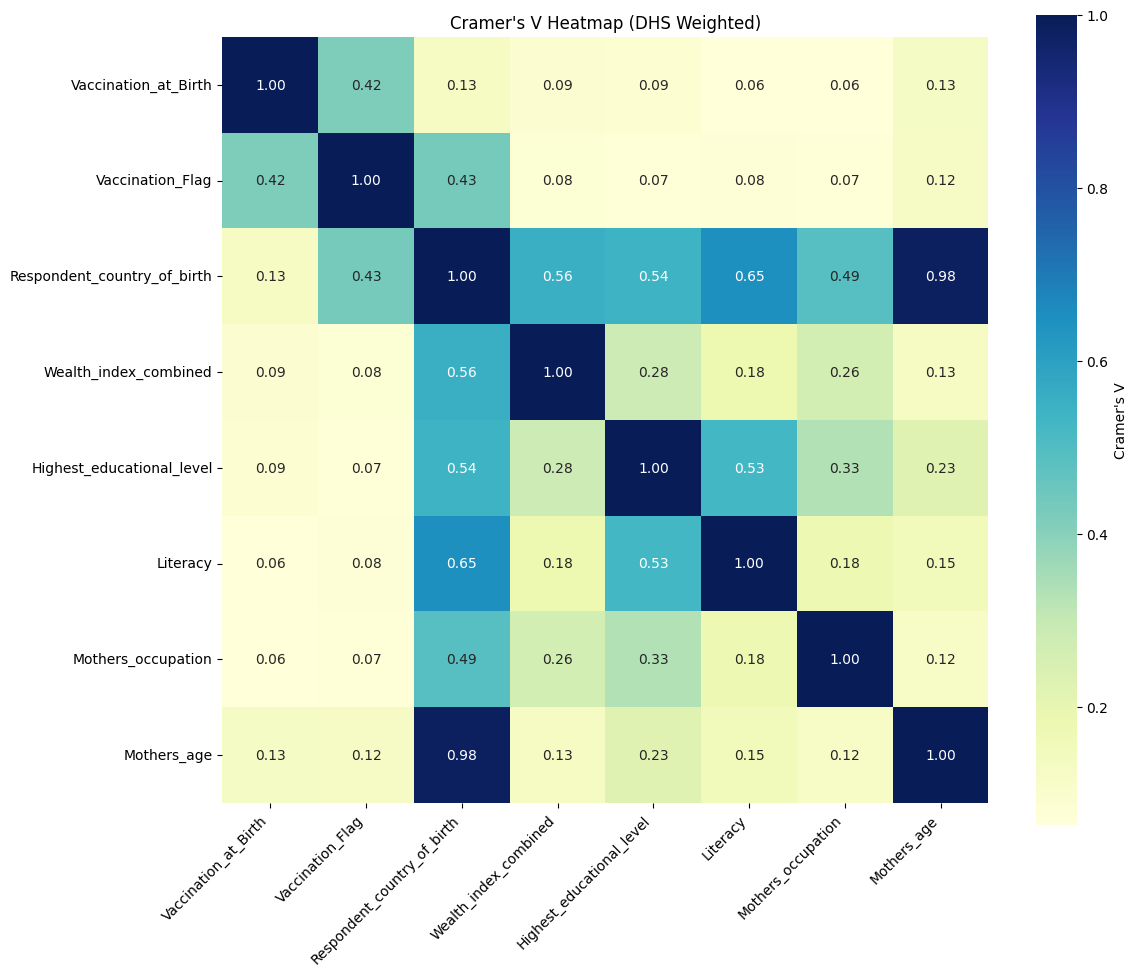

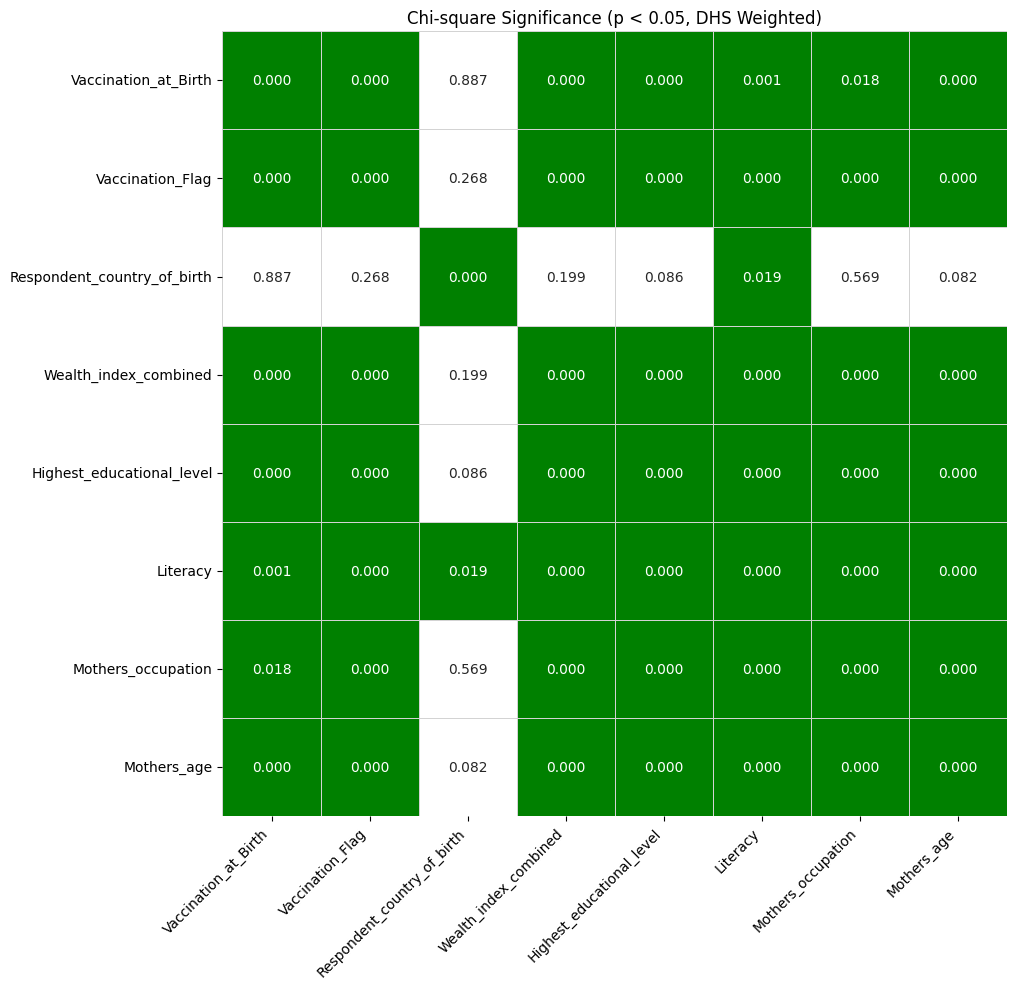

In [4]:
# ---------------------------------------------------
# 0. Select variables
# ---------------------------------------------------
weight_col = "wt"
all_vars = [col for col in df_test.columns if col != weight_col]

# ---------------------------------------------------
# 1. Pairwise loop
# ---------------------------------------------------
cramers_results = pd.DataFrame(index=all_vars, columns=all_vars, dtype=float)
chi2_p_values = pd.DataFrame(index=all_vars, columns=all_vars, dtype=float)

for var1 in all_vars:
    for var2 in all_vars:
        if var1 == var2:
            cramers_results.loc[var1, var2] = 1.0
            chi2_p_values.loc[var1, var2] = 0.0
        else:
            try:
                result = chi2_cramers_v_weighted(df_test, var1, var2, weight_col)
                cramers_results.loc[var1, var2] = result["cramers_v"]
                chi2_p_values.loc[var1, var2] = result["p_value"]
            except Exception:
                cramers_results.loc[var1, var2] = np.nan
                chi2_p_values.loc[var1, var2] = np.nan

# ---------------------------------------------------
# 2. Cramer's V Heatmap
# ---------------------------------------------------
plt.figure(figsize=(12, 10))
sns.heatmap(
    cramers_results.astype(float),
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={"label": "Cramer's V"},
    square=True
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("Cramer's V Heatmap (DHS Weighted)")
plt.tight_layout()
plt.savefig("../output/Mothers_cramer_v.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------------------------------------------------
# 3. Chi-square Significance Heatmap
# ---------------------------------------------------
alpha = 0.05
significant_mask = chi2_p_values.astype(float) < alpha
cmap = ListedColormap(["white", "green"])

plt.figure(figsize=(12, 10))
sns.heatmap(
    significant_mask,
    cmap=cmap,
    annot=chi2_p_values.round(3),
    fmt=".3f",
    square=True,
    linewidths=0.5,
    linecolor='lightgray',
    cbar=False
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("Chi-square Significance (p < 0.05, DHS Weighted)")
plt.tight_layout()
plt.savefig("../output/Mothers_chi_squared.png", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
import pandas as pd
from src.analysis_utils import (
    drop_missing,
    recode_vaccination_variables,
    fit_weighted_ordinal_logit,
    fit_weighted_logit
)

# ---------------------------------------------------
# 1. Recode and clean
# ---------------------------------------------------
df = recode_vaccination_variables(df)
df["Wealth_Ref"] = pd.Categorical(
    df["Wealth_index_combined"],
    categories=["Middle", "Poorest", "Poorer", "Richer", "Richest"]
)
df_clean = drop_missing(df, ["Vaccination_at_Birth", "Vaccination_Flag_ord", "Wealth_Ref", "wt"])


# ---------------------------------------------------
# Binary Logistic Rregression: Wealth
# ---------------------------------------------------
df_binary_w, fit_stats_binary_w = fit_weighted_logit(
    df=df_clean,
    formula="Vaccination_at_Birth ~ Wealth_Ref",
    weight_col="wt")

print("=== Binary Logit: Odds Ratios ===")
print(df_binary_w)

print("\n=== Binary Logit: Model Fit ===")
for k, v in fit_stats_binary_w.items():
    print(f"  {k}: {v}")





# ---------------------------------------------------
# Ordinal Logistic Rregression: Residence
# ---------------------------------------------------
df_ordinal_w, fit_stats_ordinal_w = fit_weighted_ordinal_logit(
    df=df_clean,
    outcome="Vaccination_Flag_ord",
    predictors=["Wealth_Ref"],
    weight_col="wt"
)

print("=== Ordinal Logit: Odds Ratios ===")
print(df_ordinal_w)

print("\n=== Ordinal Logit: Model Fit ===")
for k, v in fit_stats_ordinal_w.items():
    print(f"  {k}: {v}")

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.
C:\Users\oscar\anaconda3\envs\Vaccination_Cambodia\Lib\site-packages\rpy2\robjects\pandas2ri.py:65: UserWarning: Error while trying to convert the column "Respondent_country_of_birth". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '


=== Binary Logit: Odds Ratios ===
                          OR   CI_lower   CI_upper    t_value       p_value
(Intercept)        15.662334  11.340520  21.631169  16.701328  6.479558e-61
Wealth_RefPoorest   0.511397   0.351338   0.744372  -3.501357  4.670999e-04
Wealth_RefPoorer    1.085656   0.691312   1.704945   0.356890  7.211894e-01
Wealth_RefRicher    1.261663   0.752424   2.115555   0.881363  3.781654e-01
Wealth_RefRichest   1.020738   0.582934   1.787347   0.071814  9.427531e-01

=== Binary Logit: Model Fit ===
  n: 4814
  log_likelihood: -1167.253420599439
  null_log_likelihood: -1185.7276970526434
  mcfadden_r2: 0.015580538853166459
  aic: 2348.255516176046
  bic: 2376.9032592905933


C:\Users\oscar\anaconda3\envs\Vaccination_Cambodia\Lib\site-packages\rpy2\robjects\pandas2ri.py:65: UserWarning: Error while trying to convert the column "Respondent_country_of_birth". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '


=== Ordinal Logit: Odds Ratios ===
                         OR  CI_lower  CI_upper    t_value   p_value
Wealth_RefPoorest  0.539452  0.416973  0.697905  -4.697373  0.000003
Wealth_RefPoorer   1.081262  0.805537  1.451364   0.520197  0.602926
Wealth_RefRicher   1.233402  0.872017  1.744555   1.185850  0.235682
Wealth_RefRichest  1.078917  0.746800  1.558733   0.404652  0.685733
0|1                0.068583  0.054736  0.085934 -23.288193  0.000000
1|2                0.112099  0.090027  0.139583 -19.561063  0.000000
2|3                0.167933  0.135889  0.207533 -16.516709  0.000000

=== Ordinal Logit: Model Fit ===
  n: 4814
  log_likelihood: -2832.7692080898814
  null_log_likelihood: -2864.8641735634797
  mcfadden_r2: 0.011202962349756596
  aic: 5679.538416179763
  bic: 5724.893401508164


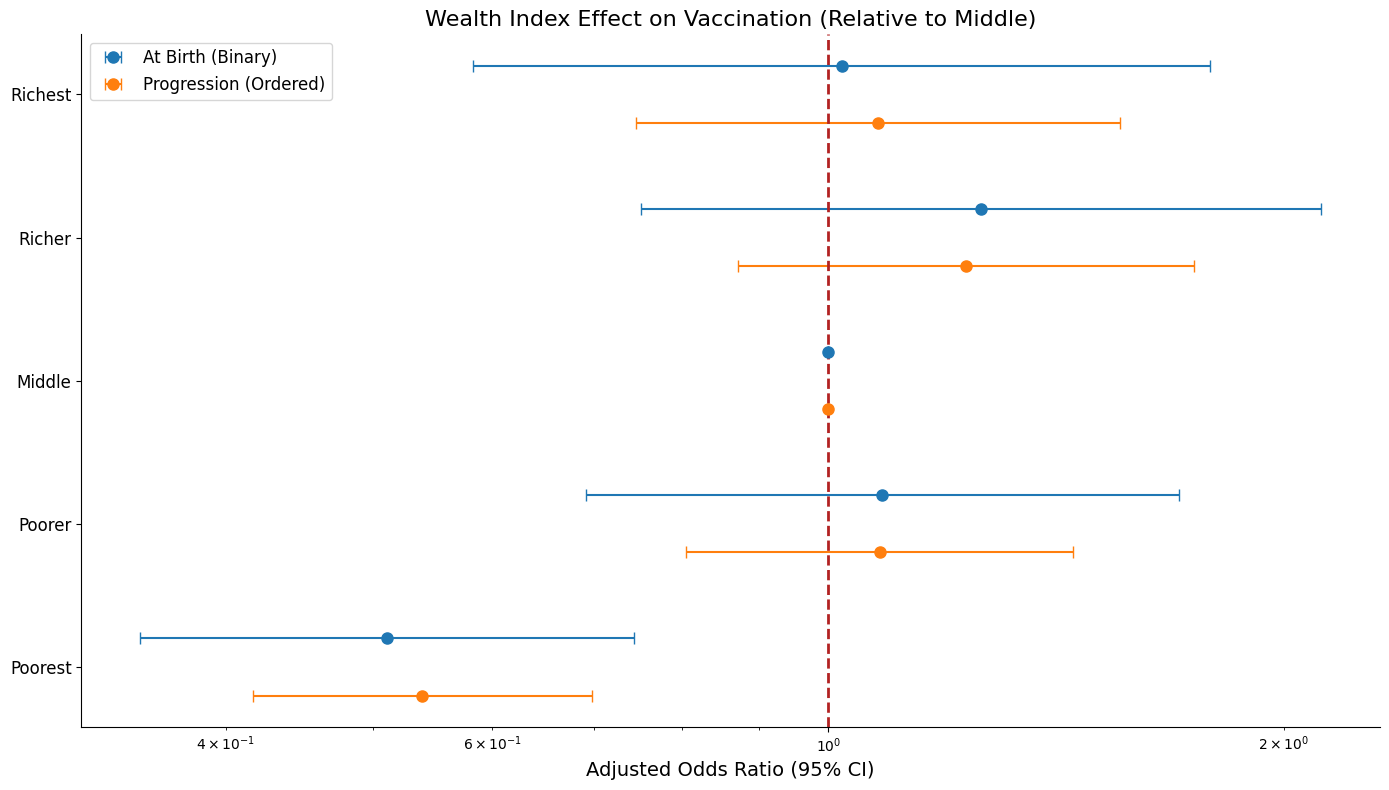

In [6]:
# ---------------------------------------------------
# Forest Plot: Wealth
# ---------------------------------------------------

# Remove intercepts and threshold cutpoints
bin_plot = df_binary_w[~df_binary_w.index.str.contains("Intercept")].copy()
ord_plot = df_ordinal_w[~df_ordinal_w.index.str.contains("Intercept|/")].copy()

# Clean up index names
bin_plot.index = bin_plot.index.str.replace("Wealth_Ref", "")
ord_plot.index = ord_plot.index.str.replace("Wealth_Ref", "")

# Add Middle reference row at OR=1
middle_row = pd.DataFrame({
    "OR": [1.0, 1.0],
    "CI_lower": [1.0, 1.0],
    "CI_upper": [1.0, 1.0],
    "t_value": [np.nan, np.nan],
    "p_value": [np.nan, np.nan]
}, index=["Middle", "Middle"])

bin_plot = pd.concat([bin_plot, middle_row.iloc[[0]]])
ord_plot = pd.concat([ord_plot, middle_row.iloc[[1]]])

# Define ordered categories
order = ["Poorest", "Poorer", "Middle", "Richer", "Richest"]
bin_plot = bin_plot.reindex(order)
ord_plot = ord_plot.reindex(order)

plot_df = pd.DataFrame({
    "Variable": order,
    "OR_Birth":  bin_plot["OR"].values,
    "LCI_Birth": bin_plot["CI_lower"].values,
    "UCI_Birth": bin_plot["CI_upper"].values,
    "OR_Prog":   ord_plot["OR"].values,
    "LCI_Prog":  ord_plot["CI_lower"].values,
    "UCI_Prog":  ord_plot["CI_upper"].values,
})

fig, ax = plt.subplots(figsize=(14, 8))
y_pos = np.arange(len(plot_df))

ax.errorbar(
    plot_df["OR_Birth"], y_pos + 0.2,
    xerr=[plot_df["OR_Birth"] - plot_df["LCI_Birth"], plot_df["UCI_Birth"] - plot_df["OR_Birth"]],
    fmt="o", markersize=8, capsize=4, label="At Birth (Binary)"
)
ax.errorbar(
    plot_df["OR_Prog"], y_pos - 0.2,
    xerr=[plot_df["OR_Prog"] - plot_df["LCI_Prog"], plot_df["UCI_Prog"] - plot_df["OR_Prog"]],
    fmt="o", markersize=8, capsize=4, label="Progression (Ordered)"
)

ax.axvline(1, color="firebrick", linestyle="--", linewidth=2)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["Variable"], fontsize=12)
ax.set_xscale("log")
ax.set_xlabel("Adjusted Odds Ratio (95% CI)", fontsize=14)
ax.set_title("Wealth Index Effect on Vaccination (Relative to Middle)", fontsize=16)
ax.legend(fontsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("../output/Forest_plot_wealth.png", dpi=300, bbox_inches="tight")
plt.show()

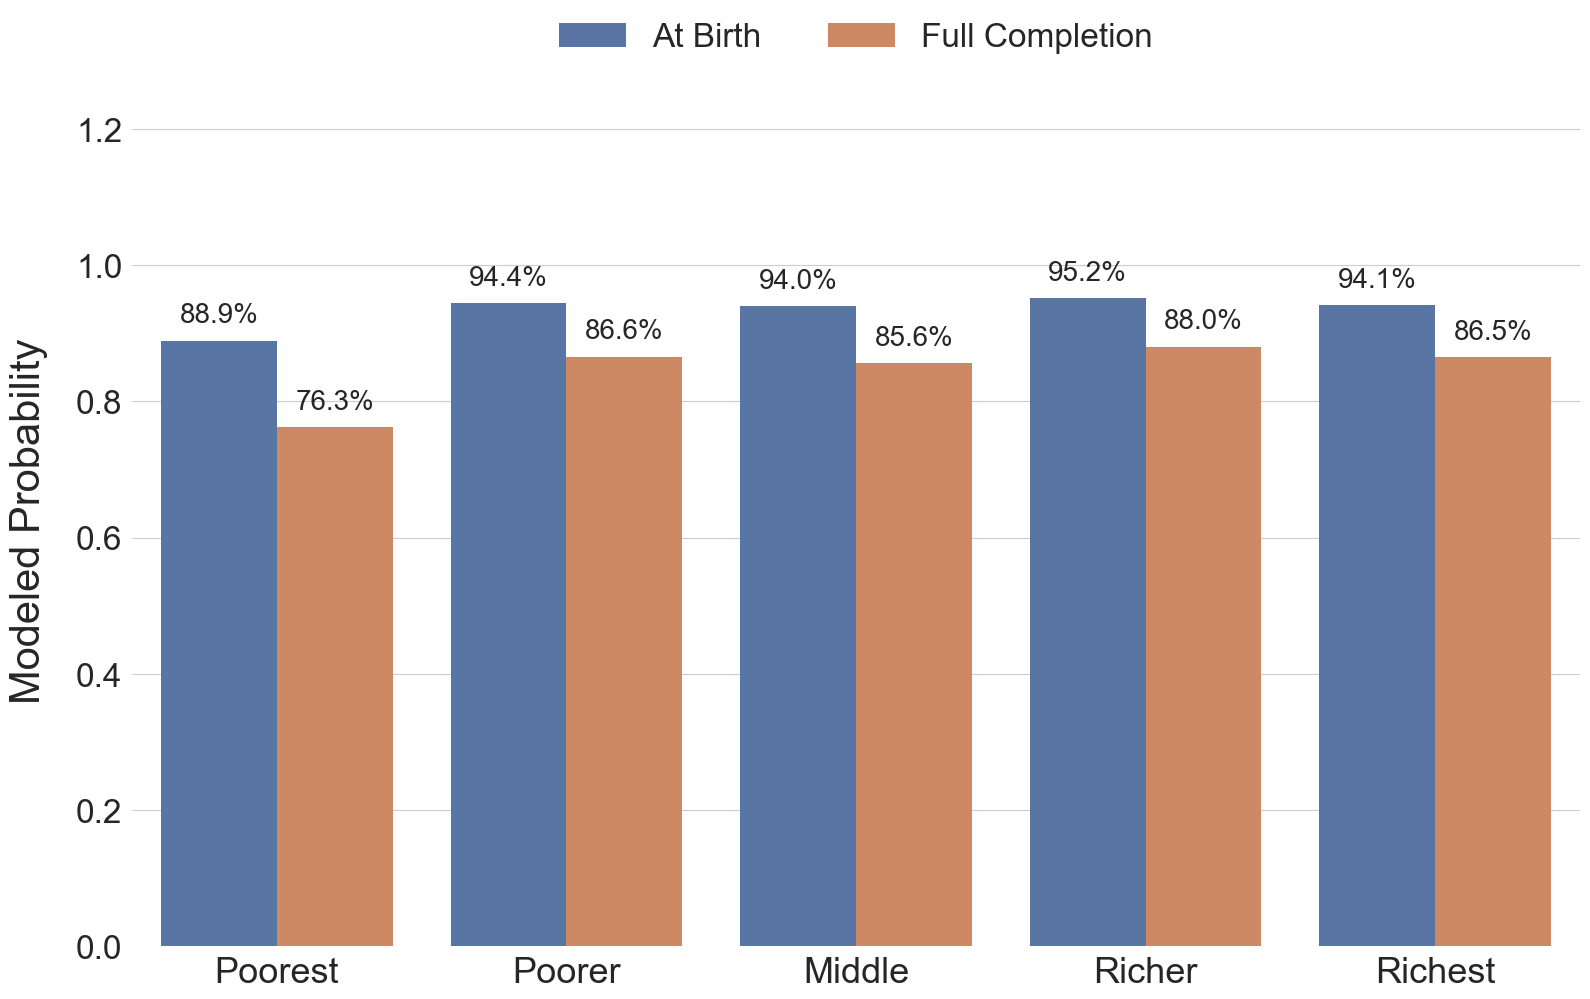

In [7]:
# ---------------------------------------------------
# Predicted Coverage by Wealth Category
# ---------------------------------------------------

# --- 1. Binary predicted probabilities ---
intercept_bin = np.log(df_binary_w.loc["(Intercept)", "OR"])
order = ["Poorest", "Poorer", "Middle", "Richer", "Richest"]

probs_birth = {}
for group in order:
    if group == "Middle":
        log_odds = intercept_bin
    else:
        coef = np.log(df_binary_w.loc[f"Wealth_Ref{group}", "OR"])
        log_odds = intercept_bin + coef
    probs_birth[group] = 1 / (1 + np.exp(-log_odds))


# --- 2. Ordinal predicted probabilities P(Full) ---
t3 = np.log(df_ordinal_w.loc["2|3", "OR"])

probs_full = {}
for group in order:
    if group == "Middle":
        coef = 0
    else:
        coef = np.log(df_ordinal_w.loc[f"Wealth_Ref{group}", "OR"])
    probs_full[group] = 1 - (1 / (1 + np.exp(-(t3 - coef))))


# 3. --- Plot ---
df_plot = pd.DataFrame({
    "Wealth Group": order * 2,
    "Stage": ["At Birth"] * 5 + ["Full Completion"] * 5,
    "Rate": list(probs_birth.values()) + list(probs_full.values())
})

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(16, 10))

sns.barplot(
    data=df_plot,
    x="Wealth Group",
    y="Rate",
    hue="Stage",
    order=order,
    palette=["#4c72b0", "#dd8452"],
    edgecolor="none"
)

ax.set_ylabel("Modeled Probability", fontsize=30, labelpad=20)
ax.set_xlabel("", fontsize=0)
ax.set_ylim(0, 1.25)
ax.legend(title="", fontsize=24, loc="upper center",
          bbox_to_anchor=(0.5, 1.12), ncol=2, frameon=False)
ax.tick_params(axis="x", labelsize=26)
ax.tick_params(axis="y", labelsize=24)

for p in ax.patches:
    h = p.get_height()
    if h > 0.01:
        ax.annotate(f"{h*100:.1f}%",
                    (p.get_x() + p.get_width() / 2., h),
                    ha="center", va="center",
                    xytext=(0, 18), textcoords="offset points",
                    fontsize=20)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.savefig("../output/Modeled_prob_wealth.png", dpi=300, bbox_inches="tight")
plt.show()

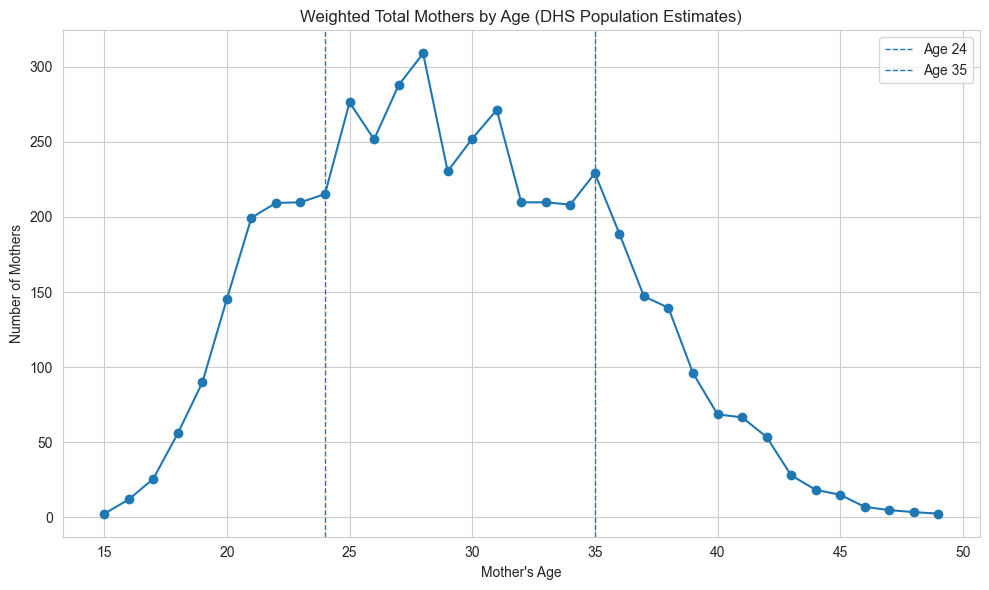

In [8]:
# ---------------------------------------------------
# Line Plot of Maternal Age with Buckets Marked
# ---------------------------------------------------

# Aggregate total mothers by age using weights
mothers_by_age = df.groupby("Mothers_age")["wt"].sum().reset_index(name="Weighted Total Mothers")

# Plot
plt.figure(figsize=(10, 6))
plt.plot(
    mothers_by_age["Mothers_age"],
    mothers_by_age["Weighted Total Mothers"],
    marker='o'
)
plt.axvline(x=24, linestyle='--', linewidth=1, label='Age 24')
plt.axvline(x=35, linestyle='--', linewidth=1, label='Age 35')
plt.title("Weighted Total Mothers by Age (DHS Population Estimates)")
plt.xlabel("Mother's Age")
plt.ylabel("Number of Mothers")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("../output/Age_buckets.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\oscar\AppData\Local\Temp\ipykernel_20772\1103800008.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: weighted_mean(g["Vaccination_at_Birth"], g["wt"]))
C:\Users\oscar\AppData\Local\Temp\ipykernel_20772\1103800008.py:32: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: weighted_mean(g["Vaccination_Flag_ord"], g["wt"]))
C:\Users\oscar\AppData\Local\Temp\ipykernel_20772\110380

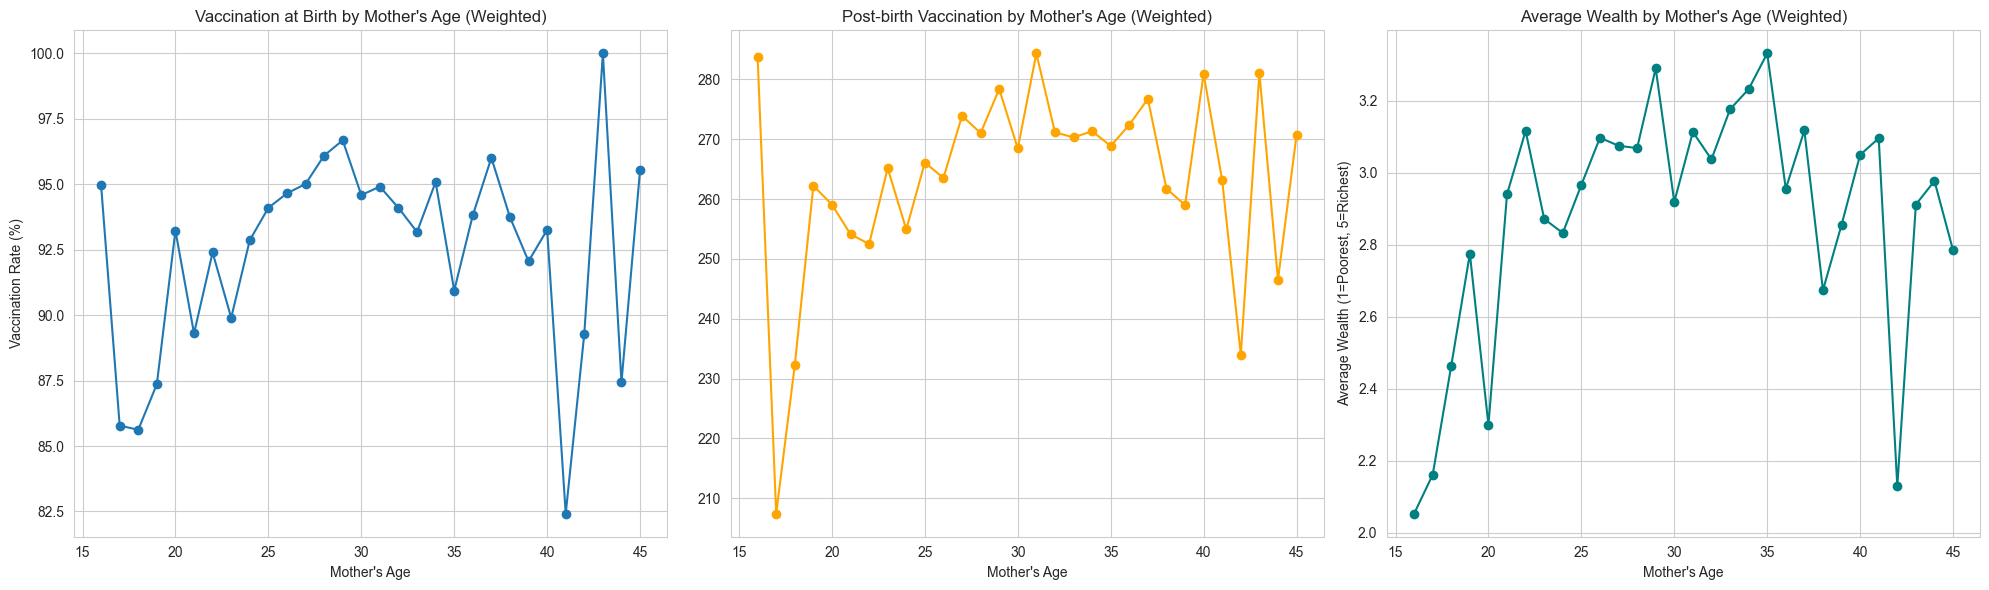

Vaccination at Birth:      weighted r = 0.020
Post-birth Vaccination:    weighted r = 0.049
Average Wealth:            weighted r = 0.046


In [9]:
# ---------------------------------------------------
# Exploratory Wealth Graphs
# ---------------------------------------------------

# --- 1. Recode and clean ---
df = recode_vaccination_variables(df)

wealth_mapping = {"Poorest": 1, "Poorer": 2, "Middle": 3, "Richer": 4, "Richest": 5}
df["Wealth_numeric"] = df["Wealth_index_combined"].map(wealth_mapping)

df_clean = drop_missing(df, ["Mothers_age", "Wealth_numeric", "Vaccination_at_Birth", "Vaccination_Flag_ord", "wt"])

# --- 2. Filter ages with enough mothers ---
min_count = 10
age_counts = df_clean.groupby("Mothers_age")["wt"].sum().reset_index(name="Weighted Count")
valid_ages = age_counts[age_counts["Weighted Count"] >= min_count]["Mothers_age"]
df_filtered = df_clean[df_clean["Mothers_age"].isin(valid_ages)]

# --- 3. Weighted aggregation ---
def weighted_mean(series, weights):
    return np.average(series, weights=weights)

vacc_by_age_birth = (
    df_filtered.groupby("Mothers_age")
    .apply(lambda g: weighted_mean(g["Vaccination_at_Birth"], g["wt"]))
    .reset_index(name="Vaccination_at_Birth")
)
vacc_by_age_birth["Pct"] = vacc_by_age_birth["Vaccination_at_Birth"] * 100

vacc_by_age_post = (
    df_filtered.groupby("Mothers_age")
    .apply(lambda g: weighted_mean(g["Vaccination_Flag_ord"], g["wt"]))
    .reset_index(name="Vaccination_Flag_ord")
)
vacc_by_age_post["Pct"] = vacc_by_age_post["Vaccination_Flag_ord"] * 100

avg_wealth_by_age = (
    df_filtered.groupby("Mothers_age")
    .apply(lambda g: weighted_mean(g["Wealth_numeric"], g["wt"]))
    .reset_index(name="Average Wealth")
)

# --- 4. Plot ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

axes[0].plot(vacc_by_age_birth["Mothers_age"], vacc_by_age_birth["Pct"], marker='o')
axes[0].set_title("Vaccination at Birth by Mother's Age (Weighted)")
axes[0].set_xlabel("Mother's Age")
axes[0].set_ylabel("Vaccination Rate (%)")
axes[0].grid(True)

axes[1].plot(vacc_by_age_post["Mothers_age"], vacc_by_age_post["Pct"], marker='o', color='orange')
axes[1].set_title("Post-birth Vaccination by Mother's Age (Weighted)")
axes[1].set_xlabel("Mother's Age")
axes[1].grid(True)

axes[2].plot(avg_wealth_by_age["Mothers_age"], avg_wealth_by_age["Average Wealth"], marker='o', color='teal')
axes[2].set_title("Average Wealth by Mother's Age (Weighted)")
axes[2].set_xlabel("Mother's Age")
axes[2].set_ylabel("Average Wealth (1=Poorest, 5=Richest)")
axes[2].grid(True)

plt.tight_layout()
plt.savefig("../output/Age_vs_vax_and_wealth.png", dpi=300, bbox_inches="tight")
plt.show()

# --- 5. Weighted correlations ---
def weighted_corr(x, y, w):
    wx = np.average(x, weights=w)
    wy = np.average(y, weights=w)
    cov = np.average((x - wx) * (y - wy), weights=w)
    varx = np.average((x - wx)**2, weights=w)
    vary = np.average((y - wy)**2, weights=w)
    return cov / np.sqrt(varx * vary)

r_birth  = weighted_corr(df_filtered["Mothers_age"], df_filtered["Vaccination_at_Birth"], df_filtered["wt"])
r_post   = weighted_corr(df_filtered["Mothers_age"], df_filtered["Vaccination_Flag_ord"], df_filtered["wt"])
r_wealth = weighted_corr(df_filtered["Mothers_age"], df_filtered["Wealth_numeric"], df_filtered["wt"])

print(f"Vaccination at Birth:      weighted r = {r_birth:.3f}")
print(f"Post-birth Vaccination:    weighted r = {r_post:.3f}")
print(f"Average Wealth:            weighted r = {r_wealth:.3f}")

C:\Users\oscar\AppData\Local\Temp\ipykernel_20772\3875134993.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  temp = df_media.groupby("Mothers_age").apply(
C:\Users\oscar\AppData\Local\Temp\ipykernel_20772\3875134993.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  temp = df_media.groupby("Mothers_age").apply(
C:\Users\oscar\AppData\Local\Temp\ipykernel_20772\3875134993.py:39: FutureWarning: DataFrameGroupBy.

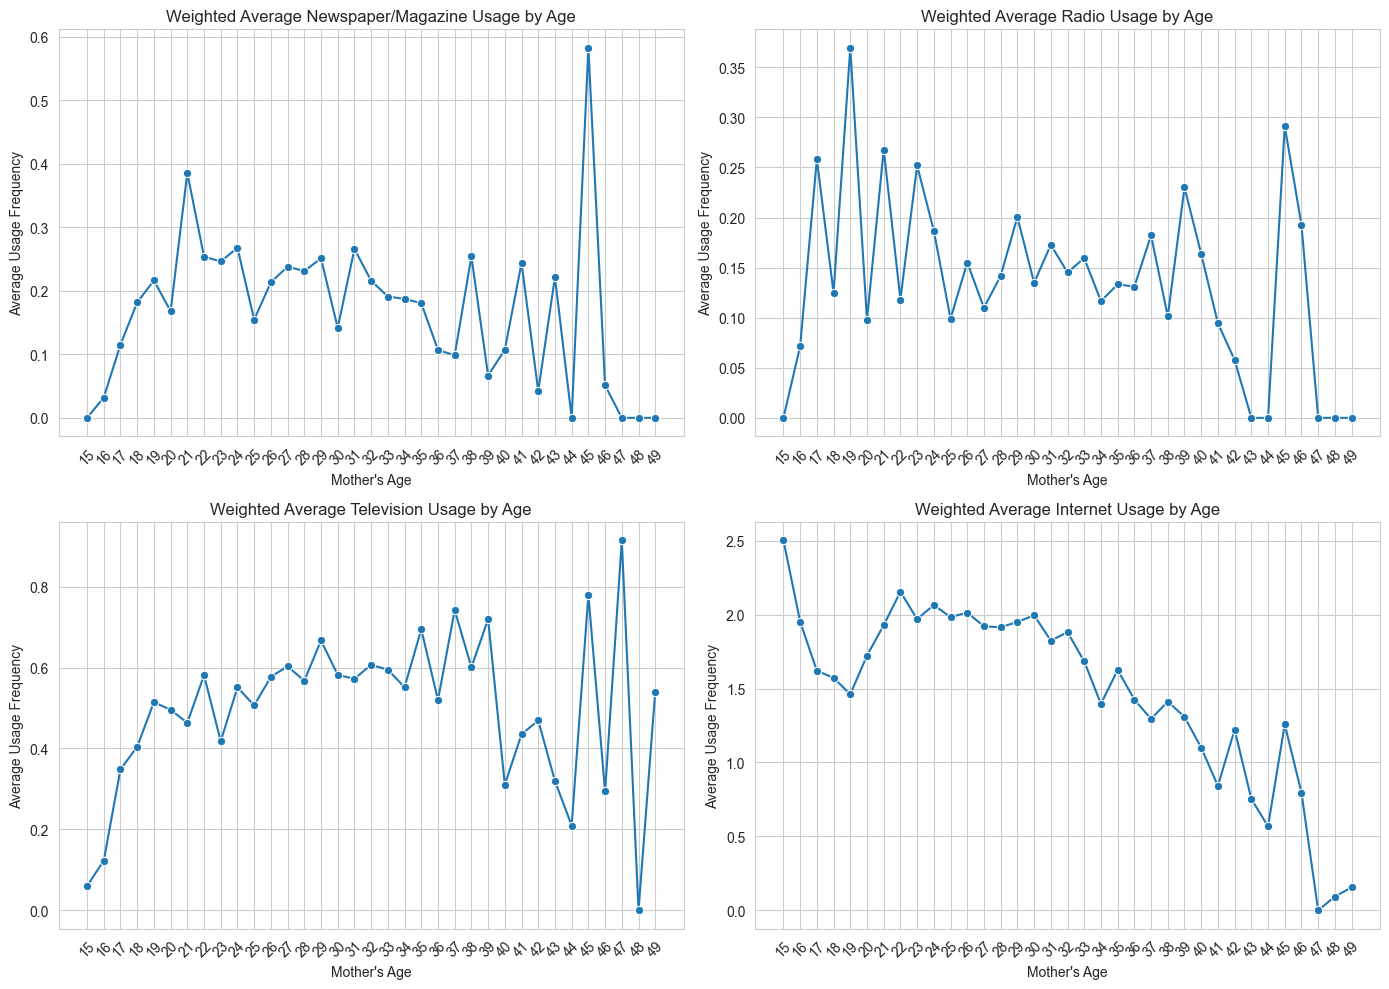

Frequency_of_reading_newspaper_or_magazine weighted range: 0 - 2
Frequency_of_listening_to_radio weighted range: 0 - 2
Frequency_of_watching_television weighted range: 0 - 2
Frequency_of_using_internet_last_month weighted range: 0 - 3


In [10]:
# ---------------------------------------------------
# Plots of Media Usage by Maternal Age
# ---------------------------------------------------

# --- 1. Define media variables ---
media_vars = [
    "Frequency_of_reading_newspaper_or_magazine",
    "Frequency_of_listening_to_radio",
    "Frequency_of_watching_television",
    "Frequency_of_using_internet_last_month"
]
titles = ["Newspaper/Magazine", "Radio", "Television", "Internet"]

# --- 2. Map to numeric ---
text_to_numeric = {
    "Not at all": 0,
    "Less than once a week": 1,
    "At least once a week": 2,
    "Almost every day": 3
}
for col in media_vars:
    df[col] = df[col].map(text_to_numeric)

# --- 3. Clean ---
df_media = drop_missing(df, media_vars + ["Mothers_age", "wt"])

# --- 4. Weighted mean function ---
def weighted_mean(series, weights):
    mask = series.notna() & weights.notna()
    if mask.sum() == 0:
        return np.nan
    return np.average(series[mask], weights=weights[mask])

# --- 5. Plot ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (media, title) in enumerate(zip(media_vars, titles)):
    temp = df_media.groupby("Mothers_age").apply(
        lambda g: weighted_mean(g[media], g["wt"])
    ).reset_index(name=f"Weighted_{media}")

    sns.lineplot(
        data=temp,
        x="Mothers_age",
        y=f"Weighted_{media}",
        marker='o',
        ax=axes[i]
    )

    axes[i].set_title(f"Weighted Average {title} Usage by Age")
    axes[i].set_xlabel("Mother's Age")
    axes[i].set_ylabel("Average Usage Frequency")
    axes[i].set_xticks(temp["Mothers_age"])
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("../output/Media_usage_by_age.png", dpi=300, bbox_inches="tight")
plt.show()

# --- 6. Inspect weighted ranges ---
for col in media_vars:
    print(f"{col} weighted range: {df_media[col].min()} - {df_media[col].max()}")

In [11]:
# ---------------------------------------------------
# Media Usage by Vaccination Classification
# ---------------------------------------------------

media_vars = [
    "Frequency_of_reading_newspaper_or_magazine",
    "Frequency_of_listening_to_radio",
    "Frequency_of_watching_television",
    "Frequency_of_using_internet_last_month"
]

# --- Weighted mean function ---
def weighted_mean(series, weights):
    mask = series.notna() & weights.notna()
    if mask.sum() == 0:
        return np.nan
    return np.average(series[mask], weights=weights[mask])

# --- Weighted averages by vaccination status ---
weighted_avg_list = []
for vax_status, group in df.groupby("Vaccination_Flag"):
    avg_dict = {col: weighted_mean(group[col], group["wt"]) for col in media_vars}
    weighted_avg_list.append(pd.Series(avg_dict, name=vax_status))

avg_usage_by_vax_weighted = pd.DataFrame(weighted_avg_list)

# --- Overall weighted average ---
overall_avg = pd.Series(
    {col: weighted_mean(df[col], df["wt"]) for col in media_vars},
    name="Overall"
)

# --- Combine and transpose ---
avg_usage_weighted = pd.concat([avg_usage_by_vax_weighted, overall_avg.to_frame().T])
avg_usage_transposed = avg_usage_weighted.T
print(avg_usage_transposed)

                                               First      Full  \
Frequency_of_reading_newspaper_or_magazine  0.120552  0.214251   
Frequency_of_listening_to_radio             0.079406  0.161130   
Frequency_of_watching_television            0.454163  0.584403   
Frequency_of_using_internet_last_month      1.710597  1.794134   

                                            None Post Birth    Second  \
Frequency_of_reading_newspaper_or_magazine         0.221815  0.128377   
Frequency_of_listening_to_radio                    0.171579  0.080574   
Frequency_of_watching_television                   0.437880  0.389543   
Frequency_of_using_internet_last_month             1.453515  1.563684   

                                             Overall  
Frequency_of_reading_newspaper_or_magazine  0.207220  
Frequency_of_listening_to_radio             0.155011  
Frequency_of_watching_television            0.560210  
Frequency_of_using_internet_last_month      1.756564  


C:\Users\oscar\AppData\Local\Temp\ipykernel_20772\1179828169.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  temp = df_media.groupby("Wealth_numeric").apply(
C:\Users\oscar\AppData\Local\Temp\ipykernel_20772\1179828169.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  temp = df_media.groupby("Wealth_numeric").apply(
C:\Users\oscar\AppData\Local\Temp\ipykernel_20772\1179828169.py:33: FutureWarning: DataFrameGr

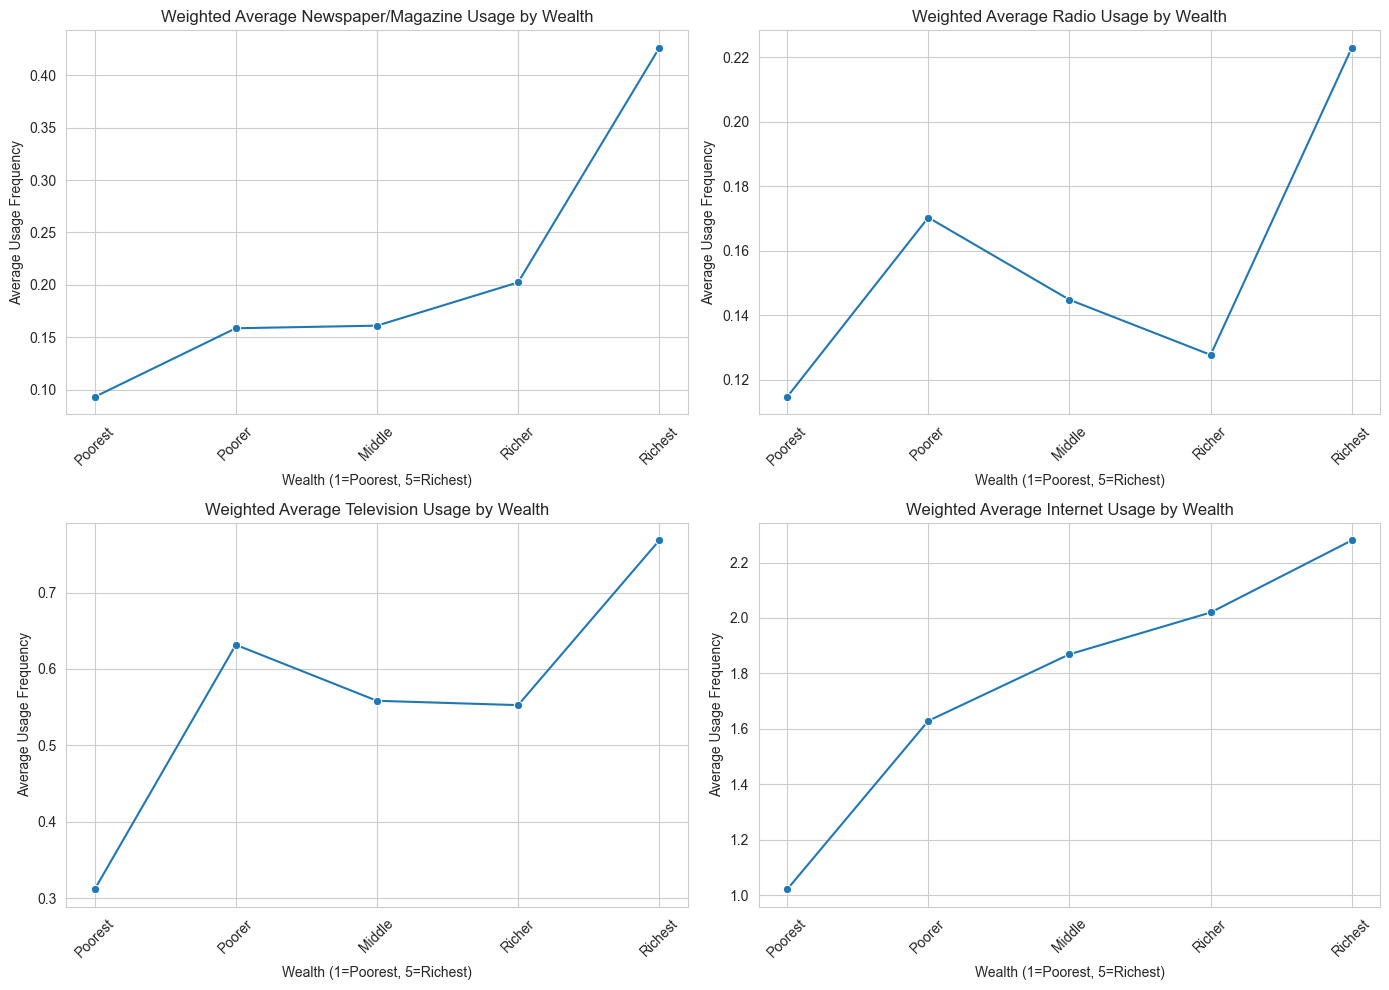

Frequency_of_reading_newspaper_or_magazine weighted range: 0 - 2
Frequency_of_listening_to_radio weighted range: 0 - 2
Frequency_of_watching_television weighted range: 0 - 2
Frequency_of_using_internet_last_month weighted range: 0 - 3


In [12]:
# ---------------------------------------------------
# Media Usage by Wealth
# ---------------------------------------------------

# --- 1. Wealth numeric mapping ---
wealth_mapping = {"Poorest": 1, "Poorer": 2, "Middle": 3, "Richer": 4, "Richest": 5}
df["Wealth_numeric"] = df["Wealth_index_combined"].map(wealth_mapping)

# --- 2. Media variables ---
media_vars = [
    "Frequency_of_reading_newspaper_or_magazine",
    "Frequency_of_listening_to_radio",
    "Frequency_of_watching_television",
    "Frequency_of_using_internet_last_month"
]
titles = ["Newspaper/Magazine", "Radio", "Television", "Internet"]

# --- 3. Clean ---
df_media = drop_missing(df, media_vars + ["Wealth_numeric", "wt"])

# --- 4. Weighted mean function ---
def weighted_mean(series, weights):
    mask = series.notna() & weights.notna()
    if mask.sum() == 0:
        return np.nan
    return np.average(series[mask], weights=weights[mask])

# --- 5. Plot ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (media, title) in enumerate(zip(media_vars, titles)):
    temp = df_media.groupby("Wealth_numeric").apply(
        lambda g: weighted_mean(g[media], g["wt"])
    ).reset_index(name=f"Weighted_{media}")

    sns.lineplot(
        data=temp,
        x="Wealth_numeric",
        y=f"Weighted_{media}",
        marker='o',
        ax=axes[i]
    )

    axes[i].set_title(f"Weighted Average {title} Usage by Wealth")
    axes[i].set_xlabel("Wealth (1=Poorest, 5=Richest)")
    axes[i].set_ylabel("Average Usage Frequency")
    axes[i].set_xticks([1, 2, 3, 4, 5])
    axes[i].set_xticklabels(["Poorest", "Poorer", "Middle", "Richer", "Richest"], rotation=45)

plt.tight_layout()
plt.savefig("Figures/Media_usage_by_age.png", dpi=300, bbox_inches="tight")
plt.show()

# --- 6. Inspect ranges ---
for col in media_vars:
    print(f"{col} weighted range: {df_media[col].min()} - {df_media[col].max()}")

In [13]:
# ---------------------------------------------------
# Comparison of Literacy and Education against Vaccination
# ---------------------------------------------------

# --- 1. Numeric mappings ---
edu_map = {"No education": 0, "Primary": 1, "Secondary": 2, "Higher": 3}
lit_map = {"Cannot read at all": 0, "Able to read only parts of a sentence": 1, "Able to read whole sentence": 2}

df["edu_numeric"] = df["Highest_educational_level"].map(edu_map)
df["lit_numeric"] = df["Literacy"].map(lit_map)

# --- 2. Weighted correlation function ---
def weighted_corr(x, y, w):
    wx = np.average(x, weights=w)
    wy = np.average(y, weights=w)
    cov = np.average((x - wx) * (y - wy), weights=w)
    varx = np.average((x - wx)**2, weights=w)
    vary = np.average((y - wy)**2, weights=w)
    return cov / np.sqrt(varx * vary)

# --- 3. Correlations with Vaccination_Flag_ord ---
results_flag = []
for label, col in [("Education", "edu_numeric"), ("Literacy", "lit_numeric")]:
    valid = drop_missing(df[[col, "Vaccination_Flag_ord", "wt"]], [col, "Vaccination_Flag_ord", "wt"])
    corr = weighted_corr(valid[col].astype(float), valid["Vaccination_Flag_ord"].astype(float), valid["wt"].astype(float))
    results_flag.append({"Factor": label, "Weighted Correlation (Flag)": corr})

print(pd.DataFrame(results_flag))

# --- 4. Correlations with Vaccination_at_Birth ---
results_birth = []
for label, col in [("Education", "edu_numeric"), ("Literacy", "lit_numeric")]:
    valid = drop_missing(df[[col, "Vaccination_at_Birth", "wt"]], [col, "Vaccination_at_Birth", "wt"])
    corr = weighted_corr(valid[col].astype(float), valid["Vaccination_at_Birth"].astype(float), valid["wt"].astype(float))
    results_birth.append({"Factor": label, "Weighted Correlation (At Birth)": corr})

print(pd.DataFrame(results_birth))

      Factor  Weighted Correlation (Flag)
0  Education                     0.095082
1   Literacy                     0.106970
      Factor  Weighted Correlation (At Birth)
0  Education                         0.074227
1   Literacy                         0.059869


C:\Users\oscar\anaconda3\envs\Vaccination_Cambodia\Lib\site-packages\rpy2\robjects\pandas2ri.py:65: UserWarning: Error while trying to convert the column "Respondent_country_of_birth". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '
C:\Users\oscar\anaconda3\envs\Vaccination_Cambodia\Lib\site-packages\rpy2\robjects\pandas2ri.py:65: UserWarning: Error while trying to convert the column "Respondent_country_of_birth". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '
C:\Users\oscar\anaconda3\envs\Vacc


--- Binary Logit: Education (N=4809) ---
                              OR  CI_lower  CI_upper   p_value
Education_RefPrimary    2.070734  1.463096  2.930730  0.000041
Education_RefSecondary  2.405050  1.659381  3.485797  0.000004
Education_RefHigher     3.641361  1.754007  7.559553  0.000529

Fit Statistics:
  Log-Likelihood:       -1169.2415
  Null Log-Likelihood:  -1185.3436
  McFadden R²:          0.0136
  AIC:                  2347.3946
  BIC:                  2372.3960

--- Ordinal Logit: Education (N=4809) ---
                              OR  CI_lower  CI_upper       p_value
Education_RefPrimary    1.875393  1.434849  2.451198  4.165188e-06
Education_RefSecondary  2.473289  1.858461  3.291520  5.291905e-10
Education_RefHigher     2.526229  1.553797  4.107251  1.860663e-04
0|1                     0.146430  0.115048  0.186372  0.000000e+00
1|2                     0.239447  0.189914  0.301898  0.000000e+00
2|3                     0.358089  0.285792  0.448676  0.000000e+00

Fit Sta

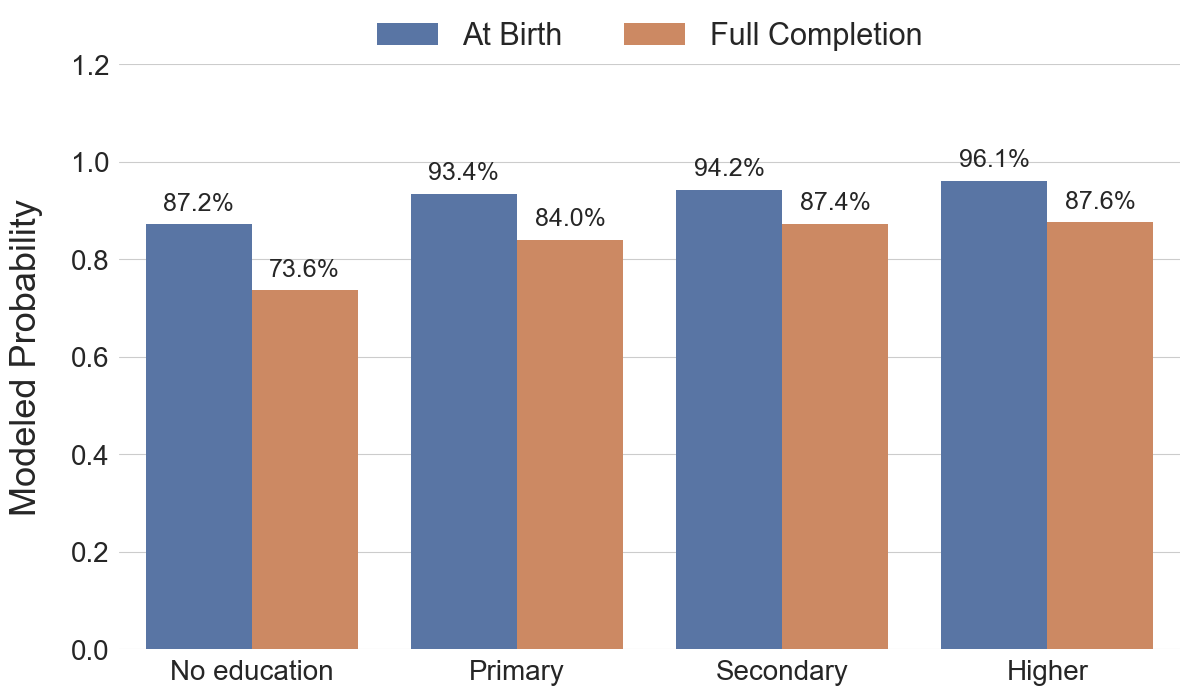

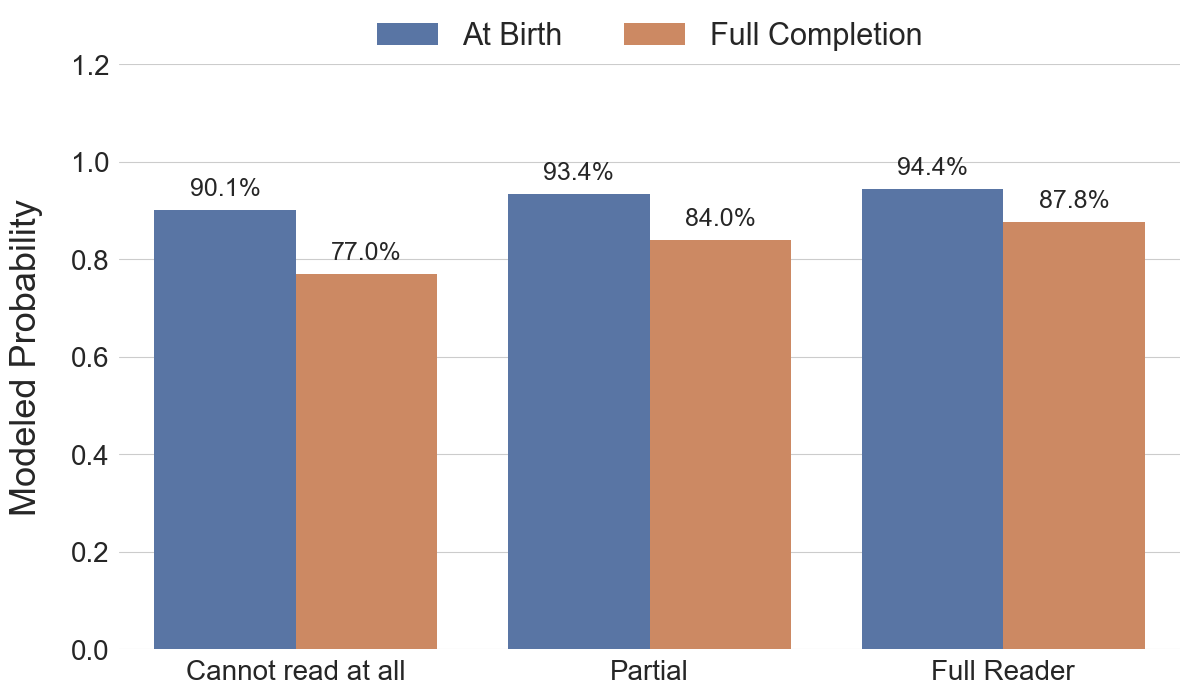

In [14]:
# ---------------------------------------------------
# Modeling of Literacy and Education against Vaccination
# ---------------------------------------------------

# ---------------------------------------------------
# 1. Recode and clean
# ---------------------------------------------------
df = recode_vaccination_variables(df)

# Set reference category to "No education" for interpretability
df["Education_Ref"] = pd.Categorical(
    df["Highest_educational_level"],
    categories=["No education", "Primary", "Secondary", "Higher"]
)

# Remap verbose literacy labels to short categories, reference = "Cannot read at all"
df["Literacy_Ref"] = pd.Categorical(
    df["Literacy"].map({
        "Cannot read at all": "Cannot read at all",
        "Able to read only parts of a sentence": "Partial",
        "Able to read whole sentence": "Full Reader"
    }),
    categories=["Cannot read at all", "Partial", "Full Reader"]
)

df_clean = drop_missing(df, ["Vaccination_at_Birth", "Vaccination_Flag_ord", "Education_Ref", "Literacy_Ref", "wt"])

# ---------------------------------------------------
# 2. Fit models
# ---------------------------------------------------

# --- Education ---
bin_edu, bin_edu_fit = fit_weighted_logit(df_clean, "Vaccination_at_Birth ~ Education_Ref", weight_col="wt")
ord_edu, ord_edu_fit = fit_weighted_ordinal_logit(df_clean, outcome="Vaccination_Flag_ord", predictors=["Education_Ref"], weight_col="wt")

# --- Literacy ---
bin_lit, bin_lit_fit = fit_weighted_logit(df_clean, "Vaccination_at_Birth ~ Literacy_Ref", weight_col="wt")
ord_lit, ord_lit_fit = fit_weighted_ordinal_logit(df_clean, outcome="Vaccination_Flag_ord", predictors=["Literacy_Ref"], weight_col="wt")

# ---------------------------------------------------
# 3. Print results and fit statistics
# ---------------------------------------------------
def print_results(label, bin_or_df, bin_fit, ord_or_df, ord_fit):
    # --- Binary logit output (excludes intercept row) ---
    print(f"\n--- Binary Logit: {label} (N={bin_fit['n']}) ---")
    print(bin_or_df[~bin_or_df.index.str.contains("Intercept")].drop(columns="t_value"))
    print("\nFit Statistics:")
    print(f"  Log-Likelihood:       {bin_fit['log_likelihood']:.4f}")
    print(f"  Null Log-Likelihood:  {bin_fit['null_log_likelihood']:.4f}")
    print(f"  McFadden R²:          {bin_fit['mcfadden_r2']:.4f}")
    print(f"  AIC:                  {bin_fit['aic']:.4f}")
    print(f"  BIC:                  {bin_fit['bic']:.4f}")
    # --- Ordinal logit output ---
    print(f"\n--- Ordinal Logit: {label} (N={ord_fit['n']}) ---")
    print(ord_or_df.drop(columns="t_value").to_string())
    print("\nFit Statistics:")
    print(f"  Log-Likelihood:       {ord_fit['log_likelihood']:.4f}")
    print(f"  Null Log-Likelihood:  {ord_fit['null_log_likelihood']:.4f}")
    print(f"  McFadden R²:          {ord_fit['mcfadden_r2']:.4f}")
    print(f"  AIC:                  {ord_fit['aic']:.4f}")
    print(f"  BIC:                  {ord_fit['bic']:.4f}")

print_results("Education", bin_edu, bin_edu_fit, ord_edu, ord_edu_fit)
print_results("Literacy",  bin_lit, bin_lit_fit, ord_lit, ord_lit_fit)

# ---------------------------------------------------
# 4. Predicted coverage probabilities
# ---------------------------------------------------
def get_probs(bin_or_df, ord_or_df, groups, prefix):
    # Intercept = log-odds of vaccination for the reference category
    intercept = np.log(bin_or_df.loc["(Intercept)", "OR"])
    # Threshold between ordinal categories 2 and 3 (used for P(Full completion))
    t3 = np.log(ord_or_df.loc["2|3", "OR"])
    probs_birth, probs_full = {}, {}
    for group in groups:
        idx = f"{prefix}{group}"
        # Reference category has no coefficient so defaults to 0
        coef_bin = np.log(bin_or_df.loc[idx, "OR"]) if idx in bin_or_df.index else 0
        coef_ord = np.log(ord_or_df.loc[idx, "OR"]) if idx in ord_or_df.index else 0
        # P(Vaccination at Birth) from binary model
        probs_birth[group] = 1 / (1 + np.exp(-(intercept + coef_bin)))
        # P(Full completion) = P(Y > 2) from ordinal model
        probs_full[group] = 1 - (1 / (1 + np.exp(-(t3 - coef_ord))))
    return probs_birth, probs_full

edu_groups = ["No education", "Primary", "Secondary", "Higher"]
lit_groups  = ["Cannot read at all", "Partial", "Full Reader"]

probs_birth_edu, probs_full_edu = get_probs(bin_edu, ord_edu, edu_groups, "Education_Ref")
probs_birth_lit, probs_full_lit = get_probs(bin_lit, ord_lit, lit_groups, "Literacy_Ref")

# ---------------------------------------------------
# 5. Plot: Modeled vaccination probabilities
# ---------------------------------------------------
unified_colors = ["#4c72b0", "#dd8452"]

def plot_vaccination_bar(groups, probs_birth, probs_full, xlabel):
    # Combine birth and full completion probabilities into long format for seaborn
    df_plot = pd.DataFrame({
        "Group": groups * 2,
        "Stage": ["At Birth"] * len(groups) + ["Full Completion"] * len(groups),
        "Rate": list(probs_birth.values()) + list(probs_full.values())
    })
    sns.set_style("whitegrid")
    fig, ax = plt.subplots(figsize=(12, 7))
    sns.barplot(
        data=df_plot,
        x="Group", y="Rate", hue="Stage",
        order=groups,
        palette=unified_colors, edgecolor="none", ax=ax
    )
    ax.set_ylabel("Modeled Probability", fontsize=26, labelpad=20)
    ax.set_xlabel("", fontsize=0)
    ax.set_ylim(0, 1.2)
    ax.tick_params(axis="x", labelsize=20)
    ax.tick_params(axis="y", labelsize=20)
    ax.legend(title="", fontsize=22, loc="upper center",
              bbox_to_anchor=(0.5, 1.12), ncol=2, frameon=False)
    # Annotate each bar with its percentage value
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.annotate(f"{h*100:.1f}%",
                        (p.get_x() + p.get_width() / 2., h),
                        ha="center", va="center",
                        xytext=(0, 15), textcoords="offset points",
                        fontsize=18)
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    # Save to output folder
    if xlabel == "Education Level":
        plt.savefig("../output/Modeled_prob_education.png", dpi=300, bbox_inches="tight")
    else:
        plt.savefig("../output/Modeled_prob_literacy.png", dpi=300, bbox_inches="tight")
    plt.show()

# ---------------------------------------------------
# 6. Generate plots for education and literacy
# ---------------------------------------------------
plot_vaccination_bar(edu_groups, probs_birth_edu, probs_full_edu, "Education Level")
plot_vaccination_bar(lit_groups, probs_birth_lit, probs_full_lit, "Literacy Level")

C:\Users\oscar\anaconda3\envs\Vaccination_Cambodia\Lib\site-packages\rpy2\robjects\pandas2ri.py:65: UserWarning: Error while trying to convert the column "Respondent_country_of_birth". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '
C:\Users\oscar\anaconda3\envs\Vaccination_Cambodia\Lib\site-packages\rpy2\robjects\pandas2ri.py:65: UserWarning: Error while trying to convert the column "Respondent_country_of_birth". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '



--- Binary Logit: Age (N=4814) ---
                    OR  CI_lower  CI_upper   p_value
Age_Cat15-24  0.531411  0.387268  0.729204  0.000091
Age_Cat35-49  0.640285  0.440211  0.931292  0.019721

Fit Statistics:
  Log-Likelihood:       -1173.8704
  Null Log-Likelihood:  -1185.7277
  McFadden R²:          0.0100
  AIC:                  2354.2202
  BIC:                  2373.1787

--- Ordinal Logit: Age (N=4814) ---
                    OR  CI_lower  CI_upper   p_value
Age_Cat15-24  0.590535  0.470963  0.740465  0.000005
Age_Cat35-49  0.815118  0.632620  1.050264  0.113931
0|1           0.061872  0.052834  0.072456  0.000000
1|2           0.100843  0.087069  0.116797  0.000000
2|3           0.150813  0.130881  0.173781  0.000000

Fit Statistics:
  Log-Likelihood:       -2849.0887
  Null Log-Likelihood:  -2864.8642
  McFadden R²:          0.0055
  AIC:                  5708.1774
  BIC:                  5740.5738


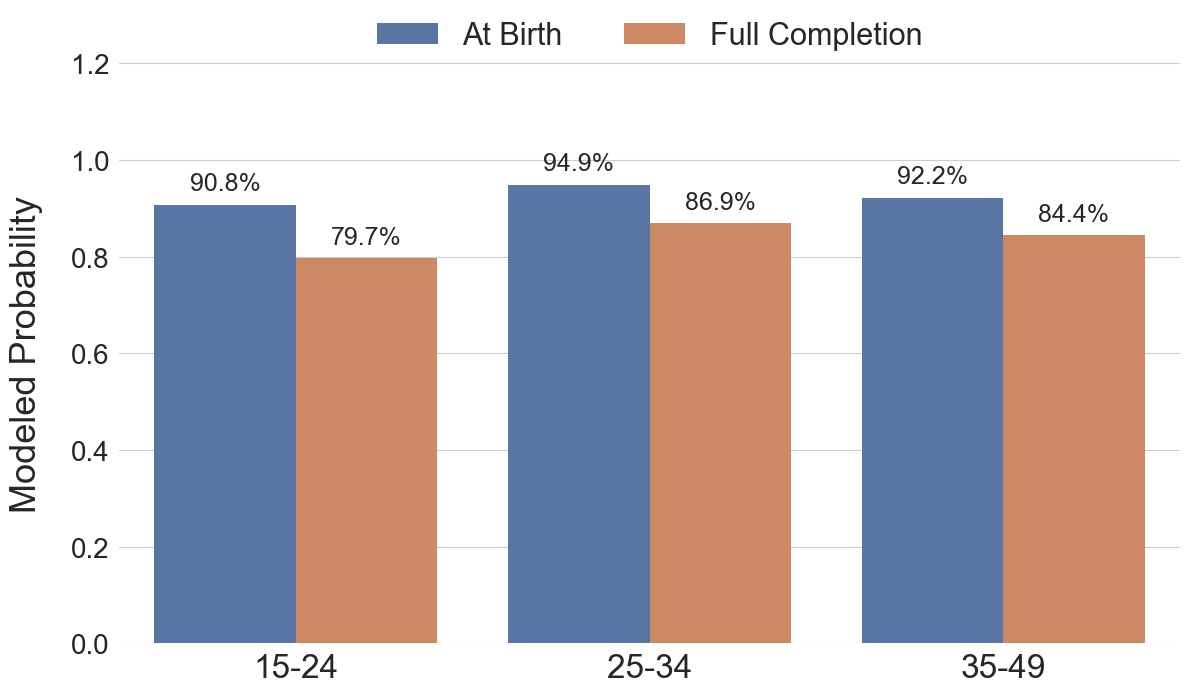

In [15]:
# ---------------------------------------------------
# Modeling of Maternal Age vs Vaccination
# ---------------------------------------------------


# ---------------------------------------------------
# 1. Recode and clean
# ---------------------------------------------------
df = recode_vaccination_variables(df)

# Bin mothers age into three groups, reference category = "25-34"
df["Age_Cat"] = pd.Categorical(
    pd.cut(df["Mothers_age"], bins=[0, 24, 34, 50], labels=["15-24", "25-34", "35-49"]),
    categories=["25-34", "15-24", "35-49"],
    ordered=False
)
df_clean = drop_missing(df, ["Vaccination_at_Birth", "Vaccination_Flag_ord", "Age_Cat", "wt"])

# ---------------------------------------------------
# 2. Fit models
# ---------------------------------------------------
bin_age, bin_fit = fit_weighted_logit(df_clean, "Vaccination_at_Birth ~ Age_Cat", weight_col="wt")
ord_age, ord_fit = fit_weighted_ordinal_logit(df_clean, outcome="Vaccination_Flag_ord", predictors=["Age_Cat"], weight_col="wt")

# ---------------------------------------------------
# 3. Print results and fit statistics
# ---------------------------------------------------
print_results("Age", bin_age, bin_fit, ord_age, ord_fit)

# ---------------------------------------------------
# 4. Predicted coverage probabilities
# ---------------------------------------------------
age_groups = ["15-24", "25-34", "35-49"]

# Intercept = log-odds of vaccination for reference category (25-34)
intercept = np.log(bin_age.loc["(Intercept)", "OR"])
# Threshold between ordinal categories 2 and 3 (used for P(Full completion))
t3 = np.log(ord_age.loc["2|3", "OR"])

probs_birth, probs_full = {}, {}
for group in age_groups:
    idx = f"Age_Cat{group}"
    # Reference category has no coefficient so defaults to 0
    coef_bin = np.log(bin_age.loc[idx, "OR"]) if idx in bin_age.index else 0
    coef_ord = np.log(ord_age.loc[idx, "OR"]) if idx in ord_age.index else 0
    # P(Vaccination at Birth) from binary model
    probs_birth[group] = 1 / (1 + np.exp(-(intercept + coef_bin)))
    # P(Full completion) = P(Y > 2) from ordinal model
    probs_full[group] = 1 - (1 / (1 + np.exp(-(t3 - coef_ord))))

# ---------------------------------------------------
# 5. Plot: Modeled vaccination probabilities by age
# ---------------------------------------------------
unified_colors = ["#4c72b0", "#dd8452"]

# Combine birth and full completion probabilities into long format for seaborn
df_plot = pd.DataFrame({
    "Group": age_groups * 2,
    "Stage": ["At Birth"] * 3 + ["Full Completion"] * 3,
    "Rate": list(probs_birth.values()) + list(probs_full.values())
})

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
    data=df_plot,
    x="Group", y="Rate", hue="Stage",
    order=age_groups,
    palette=unified_colors, edgecolor="none", ax=ax
)
ax.set_ylabel("Modeled Probability", fontsize=26, labelpad=20)
ax.set_xlabel("", fontsize=0)
ax.set_ylim(0, 1.2)
ax.tick_params(axis="x", labelsize=24)
ax.tick_params(axis="y", labelsize=20)
ax.legend(title="", fontsize=22, loc="upper center",
          bbox_to_anchor=(0.5, 1.12), ncol=2, frameon=False)

# Annotate each bar with its percentage value
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{h*100:.1f}%",
                    (p.get_x() + p.get_width() / 2., h),
                    ha="center", va="center",
                    xytext=(0, 15), textcoords="offset points",
                    fontsize=18)
sns.despine(left=True, bottom=True)
plt.tight_layout()

# ---------------------------------------------------
# Save figure to output folder
# ---------------------------------------------------
plt.savefig("../output/Modeled_prob_age.png", dpi=300, bbox_inches="tight")
plt.show()